
Feature Importance:

        Feature  Importance
9          hrmo    0.215495
10          pcv    0.210320
6            sc    0.100822
12           rc    0.087704
4           bgr    0.057824
2            al    0.054455
5            bu    0.045286
21      htn_yes    0.042061
22       dm_yes    0.038015
7           sod    0.027236
15         sg_d    0.024228
14         sg_c    0.018683
13         sg_b    0.017064
0           age    0.011617
1            bp    0.011098
3            su    0.008380
25       pe_yes    0.008308
11           wc    0.005964
17   rbc_normal    0.004478
8           pot    0.003508
18    pc_normal    0.003291
24    appet_yes    0.002636
26      ane_yes    0.000709
20   ba_present    0.000479
19  pcc_present    0.000238
23      cad_yes    0.000101
16         sg_e    0.000000

Top Features:

   Feature  Importance
9     hrmo    0.215495
10     pcv    0.210320
6       sc    0.100822
12      rc    0.087704
4      bgr    0.057824


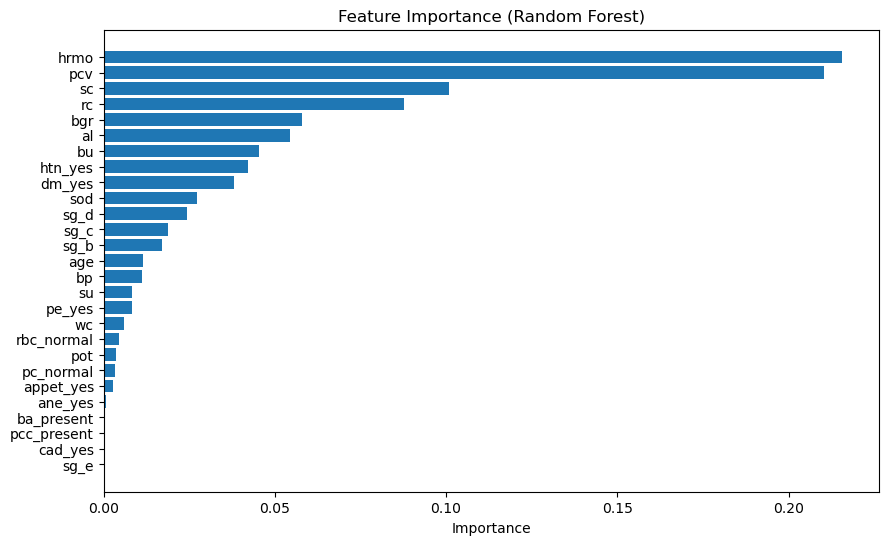

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


dataset1 = pd.read_csv("prep.csv", index_col=None)

df2 = dataset1

# Convert categorical → dummy
df2 = pd.get_dummies(df2, drop_first=True)

# Split X and Y
indep_X = df2.drop('classification_yes', axis=1)
dep_Y = df2['classification_yes']



def feature_importance(indep_X, dep_Y):
    
    from sklearn.ensemble import RandomForestClassifier
    
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(indep_X, dep_Y)
    
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': indep_X.columns,
        'Importance': importances
    })
    
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    return importance_df, model



importance_df, model = feature_importance(indep_X, dep_Y)

print("\nFeature Importance:\n")
print(importance_df)


top_n = 5
top_features = importance_df.head(top_n)

print("\nTop Features:\n")
print(top_features)


plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()
